# Import Packages

In [14]:
from glob import glob
import random
import warnings
import matplotlib.pyplot as plt
from cmcrameri import cm
import seaborn as sns
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import geopandas as gpd
from numpy import abs, nanpercentile, arange
from pathlib import Path

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style('whitegrid')
%matplotlib inline
cmap = cm.managua

fs = 12

# Settings

In [15]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

dir_results = '../output/gev_analysis/2026-03-20/'
dir_data_pkl = '../output/gev_analysis/2026-03-20/data.parquet'

In [16]:
HINDCAST_START = 1960
HINDCAST_END = 2026

In [17]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [18]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [19]:
CONFIDENCE_INTERVAL = 0.9 # two-side 90% CI interval (5% each side)

In [20]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0 #random.choice(arange(0, 9579))
end_location = 2000 #start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 0–2000


# Import Data

### Import Raw Data from Models

In [ ]:
ls_files = [file for file in glob(path_data + '*.nc')]
ls_files

In [ ]:
dic_data_per_model = dbf.import_all_models(ls_files)

### Import regression results for location trend regression

In [21]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(dir_results)

loading ../output/gev_analysis/2026-03-20//stationary_per_year.pkl
loading ../output/gev_analysis/2026-03-20//nonstationary.pkl
loading ../output/gev_analysis/2026-03-20//LatLon.pkl
loading ../output/gev_analysis/2026-03-20//location_info.pkl


# Data Processing...

### BiasCorrection,...

In [ ]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [ ]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

# VISUALS

### Plot Map of Missing Data

In [ ]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

In [ ]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, dir_export='output/exploration/'
    )

In [ ]:
display(fig_map)

### Regression Plot $μ$ - non-stationary vs annual stationary

compute with standardized or non-standardized years

#### Compute for 1 Sample

In [9]:
ls_missing = []
loc_id = random.choice(list(results_annual_stat_all.keys()))

print(f'Compute regression analysis for μ₁ for site {loc_id}...')

Compute regression analysis for μ₁ for site 1357...


In [10]:
if results_nonstat_all[loc_id] is None:
    ls_missing.append(loc_id)
    print(f'Could not process side {loc_id}, NO nonstationary results available (counting {len(ls_missing)})')

years_, dic_trend = gev.prepare_for_regression(    
    annual_stationary=results_annual_stat_all[loc_id], 
    nonstationary=results_nonstat_all[loc_id],
    confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000,
    years_scaled=True
    ) 

annual stat LSR results 671.14mm + 0.55mm • t
non-stationary regression results 683.91mm + 0.17mm • t


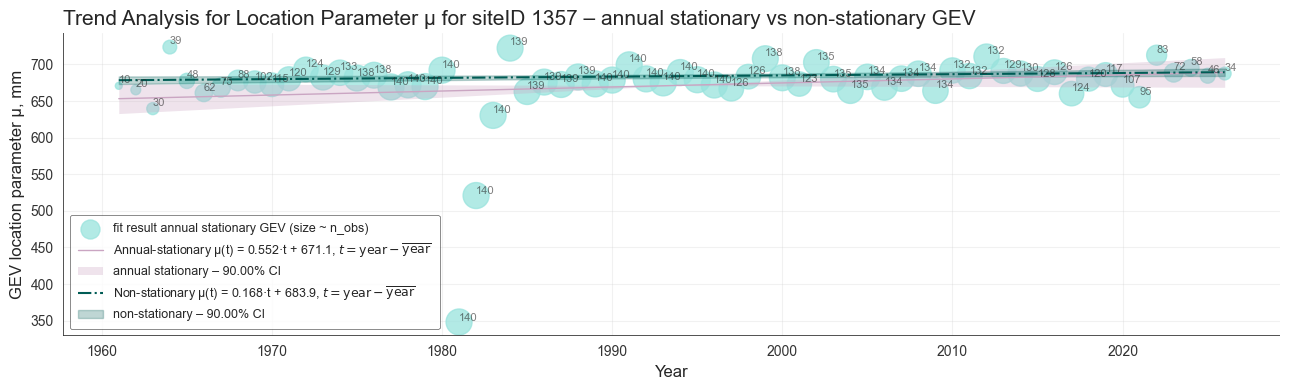

In [11]:
fig_reg = dbplt.plot_location_regression(
    loc_id, years_, dic_trend, results_annual_stat_all[loc_id], 
    confidence_level_pc=CONFIDENCE_INTERVAL, display_results=True, years_scaled=True,
    axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF', '#005C55FF'], 
    fontsize=12, 
    )

#### Compute for All

processing site 0...
annual stat LSR results 125.51mm + -0.03mm • t
non-stationary regression results 125.56mm + -0.01mm • t
processing site 1...
annual stat LSR results 125.82mm + -0.02mm • t
non-stationary regression results 125.71mm + -0.01mm • t
processing site 2...
annual stat LSR results 125.54mm + -0.02mm • t
non-stationary regression results 125.43mm + -0.01mm • t
processing site 3...
annual stat LSR results 125.70mm + -0.02mm • t
non-stationary regression results 125.62mm + -0.01mm • t
processing site 4...
annual stat LSR results 127.78mm + 0.24mm • t
non-stationary regression results 131.22mm + -0.06mm • t
processing site 5...
annual stat LSR results 123.84mm + -0.21mm • t
non-stationary regression results 125.62mm + -0.01mm • t
processing site 6...
annual stat LSR results 125.24mm + -0.03mm • t
non-stationary regression results 125.40mm + -0.01mm • t
processing site 7...
annual stat LSR results 125.70mm + -0.01mm • t
non-stationary regression results 125.46mm + -0.01mm • t
p

KeyboardInterrupt: 

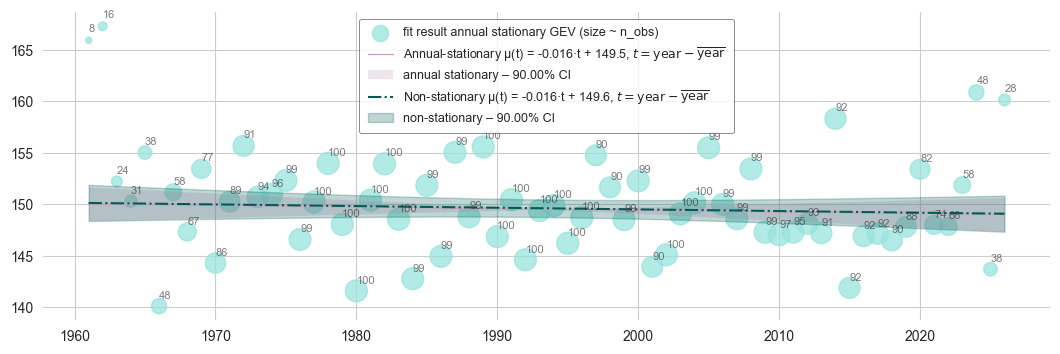

In [13]:
dic_fig_regression = {}
ls_missing = []
for loc_id in results_annual_stat_all.keys():
    if loc_id >= start_location and loc_id <= end_location:
        print(f'processing site {loc_id}...')
        
        if results_nonstat_all[loc_id] is None:
            ls_missing.append(loc_id)
            print(f'Skipping side {loc_id}, no nonstationary results (counting {len(ls_missing)})')
            dic_fig_regression[loc_id] = None
            continue
        
        years_, dic_trend = gev.prepare_for_regression(            
            annual_stationary=results_annual_stat_all[loc_id], nonstationary=results_nonstat_all[loc_id],
            confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000, years_scaled=True
            ) 

        fig_reg = dbplt.plot_location_regression(
            loc_id, years_, dic_trend, results_annual_stat_all[loc_id], fontsize=12,
            confidence_level_pc=CONFIDENCE_INTERVAL, years_scaled=True,
            axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], 
            )
        
        dic_fig_regression[loc_id] = fig_reg

In [ ]:
for loc_id in dic_fig_regression.keys():
    if dic_fig_regression[loc_id]:
        ut.store_location_regression(
            dic_fig_regression[loc_id],loc_id, 
            location_geo_info[loc_id], location_point_info[loc_id], 
            Path('../output/gev_analysis/2026-03-20/')
            )

### Plot Map of Trend for $μ_1$ | Non-Stationary and Annual

$μ_1$ with the color indicating the absolute value and the size indicating the std of $μ_1$ 

#### interactive PyDeck

In [25]:
mark_outlier = False

##### Non-Stationary Approach

In [29]:
threshold_z_outlier_ns = 3

df_plot_ns, df_mu_ns = dbplt.prep_for_plot(
    result=results_nonstat_all, location_geo_info=location_geo_info, approach='non-stationary', 
    confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier_ns
    )
print(f'\nnon-stationary data: {df_plot_ns.shape} out of {df_mu_ns.shape}')


df_plot_ns = dbplt.custom_color_for_mu1(df_plot_ns, mark_outlier=mark_outlier, min_size=2000, max_size=20000)

Marked 45 outliers using modified Z-score method
Marked 45 outliers using modified Z-score method

non-stationary data: (2001, 9) out of (2001, 5)


In [30]:
df_plot_ns[df_plot_ns['significant'] == True].mu1.describe()

count    643.000000
mean       0.019201
std        0.189329
min       -0.387709
25%       -0.121751
50%       -0.083184
75%        0.168842
max        0.530145
Name: mu1, dtype: float64

In [28]:
if mark_outlier is True:
    file_name = "Map_trend_location_including_ci_markedOutlier"
else:
    file_name = "Map_trend_location_including_ci_all"

map_ns = dbplt.plot_mu1_for_sites(
    df_plot_=df_plot_ns, inital_zoom=3.5, saving_map=True, mark_outlier=mark_outlier, 
    threshold_z_method=threshold_z_outlier_ns, approach='non-stationary approach', file_name=file_name, 
    )

map stored as %s ../output/gev_analysis/2026-03-20/figures/Map_trend_location_including_ci_all_non-stationary_approach.html


##### Annual-Stationary Approach

In [31]:
threshold_z_outlier_astat = 3

df_plot_astat, df_mu_astat = dbplt.prep_for_plot(
    result=results_annual_stat_all, location_geo_info=location_geo_info, approach='annual-stationary',
    confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier_astat
    )
print(f'\nannual stationary data: {df_plot_astat.shape} our of {df_mu_astat.shape}')

df_plot_astat = dbplt.custom_color_for_mu1(df_plot_astat, mark_outlier=mark_outlier, min_size=2000, max_size=20000)

Marked 5 outliers using modified Z-score method
Marked 5 outliers using modified Z-score method

annual stationary data: (2001, 9) our of (2001, 5)


In [32]:
df_plot_astat.mu1.describe()

count    2001.000000
mean        0.107749
std         0.438814
min        -1.559621
25%        -0.150742
50%         0.014390
75%         0.357299
max         1.618050
Name: mu1, dtype: float64

In [33]:
df_plot_astat[df_plot_astat['outliers'] == False].mu1.describe()

count    1996.000000
mean        0.107077
std         0.432934
min        -1.167393
25%        -0.150341
50%         0.014333
75%         0.356589
max         1.402405
Name: mu1, dtype: float64

In [34]:
if mark_outlier is True:
    file_name = "Map_trend_location_including_ci_markedOutlier"
else:
    file_name = "Map_trend_location_including_ci_all"

map_astat = dbplt.plot_mu1_for_sites(
    df_plot_=df_plot_astat, inital_zoom=3.5, saving_map=True, mark_outlier=mark_outlier,
    threshold_z_method=threshold_z_outlier_astat,  
    approach='annual-stationary approach', file_name=file_name, 
    )

map stored as %s ../output/gev_analysis/2026-03-20/figures/Map_trend_location_including_ci_all_annual-stationary_approach.html


#### static Matplotlib

In [35]:
def convert_ci_to_alpha(df_plot):
    max_se = nanpercentile(df_plot["mu1_std"], 98)
    df_plot['alpha'] = (1 - (df_plot['mu1_std']/max_se)).clip(0.2, 1.0)  # min alpha 0.2
    return df_plot


def convert_ci_to_markersize(df_plot, min_size=10, max_size=200):
    max_se = nanpercentile(df_plot["mu1_std"], 98)

    norm = (df_plot["mu1_std"] / max_se).clip(0, 1)

    df_plot["marker_size"] = min_size + (max_size - min_size) * norm

    return df_plot


def remove_nan_sites(df_plot):
    ls_nan_loc = []
    for en, a in enumerate(df_plot.alpha):
        if np.isnan(a):
            ls_nan_loc.append(en)
    print(f'{len(ls_nan_loc)} missing location information')

    return df_plot.dropna()


def initialize_projection(df_clean, min_size, max_size):
    gdf = gpd.GeoDataFrame(
        df_clean, geometry=gpd.points_from_xy(df_clean['lon'], df_clean['lat']),
        crs="EPSG:4326"  # WGS84
    )

    gdf_web = gdf.to_crs(epsg=3857) 
    max_abs = nanpercentile(abs(gdf['mu1']), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    # Compute marker size using your function
    max_se = nanpercentile(gdf['mu1_std'], 98)
    #gdf_web['alpha'] = (1 - (gdf_web['mu1_std']/max_se)).clip(0.2, 1.0) # high uncertainty -> more transparent marker
    #gdf_web['size'] = 20 + ((gdf_web['mu1_std']/max_se)).clip(0,1) * 180 # high uncertainty -> large marker size
    gdf_web = convert_ci_to_markersize(gdf_web, min_size=min_size, max_size=max_size)  # high uncertainty → large marker
    
    return gdf_web, norm


def plot_mu1_for_all_sites_v2(
    df_clean, approach, min_size, max_size,
    ms=80, edgecolor_marker=None, lw_marker=0.1, figsize=(8,5), display_results:bool=True, save_plot:bool=False, 
    save_path:str|None=None
    ):
    
    gdf_web, norm = initialize_projection(df_clean, min_size, max_size)
    
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(
        gdf_web.geometry.x, gdf_web.geometry.y,
        c=gdf_web['mu1'], cmap=cmap, norm=norm, s=gdf_web['marker_size'],
        edgecolor=edgecolor_marker, linewidth=lw_marker # alpha=gdf_web['alpha'], 
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

    ax.set_axis_off()  
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Location trend $μ_1$, mm/year")

    plt.title(f"Trend Map $μ_1$ · {approach}", loc='left')
    plt.text(
        x=0.625, y=0.05, 
        #x=0.005, y=1.025, 
        s="Marker size ~ uncertainty (high → large)",
        transform=ax.transAxes,  # use axes coordinates
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.35')
    )

    plt.tight_layout()
    if save_plot:
        if save_path is None:
            raise ValueError('Missing path for output; provide `save_path`...')
        
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True) 
    
        file_name = save_dir / f"Map_trend_location_including_ci_{approach}_approach.png"
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    plt.show() if display_results else plt.close(fig)
    return fig

##### Non-Stationary Approach

In [36]:
df_clean_ns = remove_nan_sites(df_plot_ns)

0 missing location information


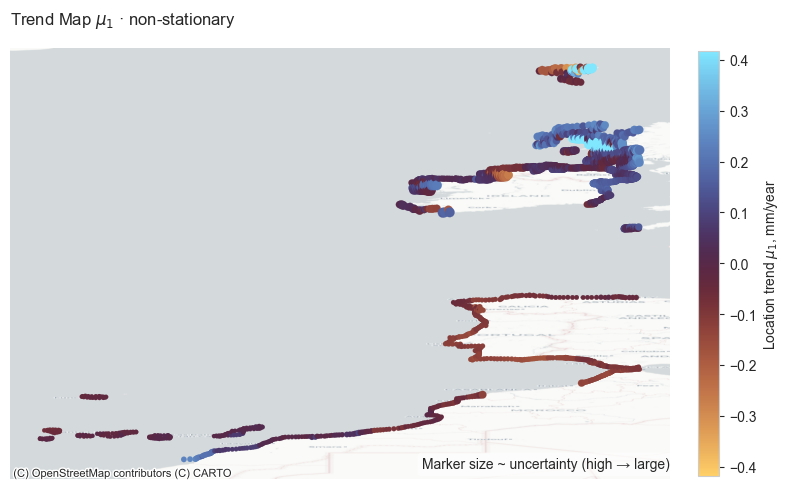

In [37]:
fig_ns = plot_mu1_for_all_sites_v2(
    df_clean_ns, approach='non-stationary', ms=5, min_size=5, max_size=50,
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-16/figures/'
    )

##### Annual-Stationary Approach

In [38]:
#df_plot_astat = convert_ci_to_alpha(df_plot_astat)
df_clean_astat = remove_nan_sites(df_plot_astat)

0 missing location information


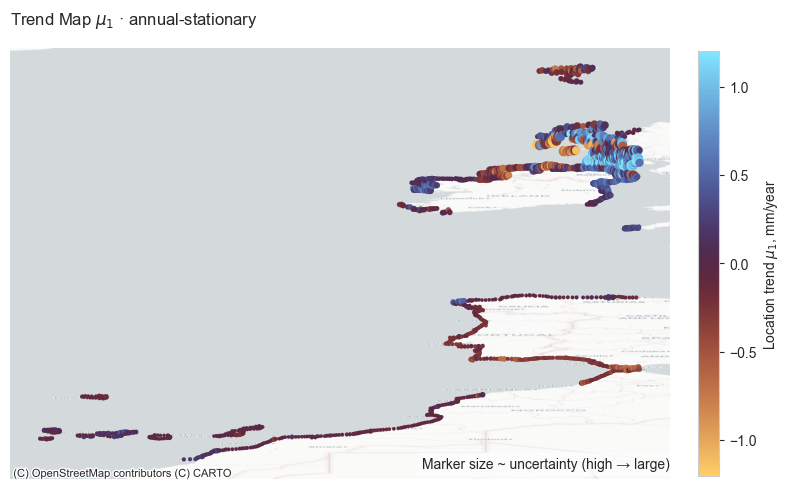

In [39]:
fig_astat = plot_mu1_for_all_sites_v2(
    df_clean_astat, approach='annual-stationary', ms=5, min_size=5, max_size=50, 
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-16/figures/'
    )